In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import functions
from FNO_vmapped import *
import pybamm
import flax
import functools
import optax

In [3]:
anode_file = "trained_models/anode_GRF__2025-03-31_00-38-52.msgpack"
cathode_file = "trained_models/cathode_GRF__2025-03-31_01-26-36.msgpack"

train_data = np.load("data/spm/for_soc/test/GRF_2200.npz")
test_data = np.load("data/spm/for_soc/test/GRF_2200.npz")

In [4]:
train_I = jnp.array(train_data["current"])
test_I = jnp.array(test_data["current"])

train_cn_anode = jnp.array(train_data["target_concentration_anode"])
test_cn_anode = jnp.array(test_data["target_concentration_anode"])

train_c0_anode = jnp.array(train_data["initial_concentration_anode"])
test_c0_anode = jnp.array(test_data["initial_concentration_anode"])

train_cn_cathode = jnp.array(train_data["target_concentration_cathode"])
test_cn_cathode = jnp.array(test_data["target_concentration_cathode"])

train_c0_cathode = jnp.array(train_data["initial_concentration_cathode"])
test_c0_cathode = jnp.array(test_data["initial_concentration_cathode"])

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

In [5]:
params_anode = functions.load_model_params(anode_file)
params_cathode = functions.load_model_params(cathode_file)

In [8]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

parameter_name = "Chen2020"
params_bat = pybamm.ParameterValues(parameter_name)

C = params_bat["Nominal cell capacity [A.h]"]
Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
epsan = params_bat["Negative electrode active material volume fraction"]
epsca = params_bat["Positive electrode active material volume fraction"]
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
Lan = params_bat["Negative electrode thickness [m]"]
Lca = params_bat["Positive electrode thickness [m]"]
A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]
t_max = 900
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [9]:
socs = [0. + i*0.01 for i in range(101)]
c0s_anode = []
c0s_cathode = []
spm = pybamm.lithium_ion.SPM()
spm.events = []
sim = pybamm.Simulation(spm, parameter_values=params_bat)
for soc in socs:
    sol = sim.solve(initial_soc=soc, t_eval = t)
    c0s_anode.append(sol["Negative particle concentration"].entries[0, 0, 0])
    c0s_cathode.append(sol["Positive particle concentration"].entries[0, 0, 0])

coeff_anode = np.polyfit(c0s_anode, socs, 1)
coeff_cathode = np.polyfit(c0s_cathode, socs, 1)

soc_from_c0_anode = lambda x: jnp.polyval(coeff_anode, x)
soc_from_c0_cathode = lambda x: jnp.polyval(coeff_cathode, x)

In [10]:
@jax.jit
def soc_to_c0(soc):
    """
    Given a state-of-charge (soc) value (scalar or array), compute the corresponding
    anode and cathode initial concentrations based on the linear fits.
    
    Returns:
        A tuple (c0_anode, c0_cathode)
    """
    c0_anode = (soc - coeff_anode[1]) / coeff_anode[0]
    c0_cathode = (soc - coeff_cathode[1]) / coeff_cathode[0]
    
    c0_anode = jnp.full((20,), c0_anode)
    c0_cathode = jnp.full((20,), c0_cathode)

    return c0_anode, c0_cathode

In [11]:
c0s_anode = np.array(c0s_anode)
c0s_cathode = np.array(c0s_cathode)
total_li = np.mean(c0s_cathode*np.pi*4/3*Rca**3*cs_max_c + c0s_anode*np.pi*4/3*Ran**3*cs_max_a)

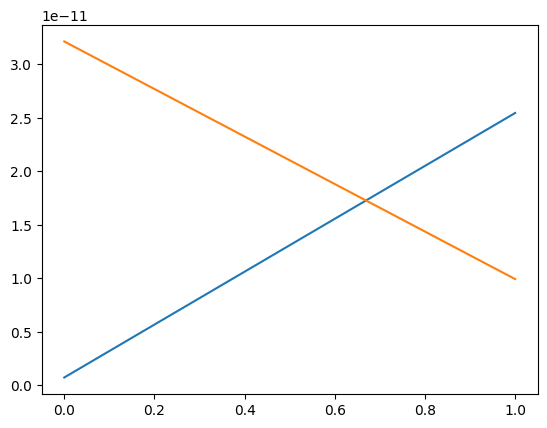

In [12]:
plt.plot(socs, c0s_anode*jnp.pi*4/3*Ran**3*cs_max_a)
plt.plot(socs, c0s_cathode*jnp.pi*4/3*Rca**3*cs_max_c)
#plt.plot(socs, c0s_cathode*jnp.pi*4/3*Rca**3*cs_max_c + c0s_anode*jnp.pi*4/3*Ran**3*cs_max_a)

In [14]:
train_idx = np.random.randint(2, 88000)
test_idx = np.random.randint(2, 8800)

In [15]:
def get_dummy_measurement(I, cn_anode, cn_cathode, noise = 0, max_retries = 1000, idx = None):

    for _ in range(max_retries):

        if np.isnan(idx):
            test_idx = np.random.randint(0, 8800)
        else:
            test_idx = idx
            
        I_test = I[test_idx]
        cn_anode_test = cn_anode[test_idx]
        cn_cathode_test = cn_cathode[test_idx]

        _, V_true = functions.post_proc(params_bat, I_test, 0, cn_anode_test[-1,:], 0, cn_cathode_test[-1,:], Ran, Rca, epsan, epsca, Lan, Lca, A)
        
        if jnp.isnan(V_true).any():
            continue
        else:
            return V_true + noise, test_idx
    
    raise ValueError("Could not produce a NaN-free measurement after {} retries.".format(max_retries))

In [25]:
######Jetzt gehts los######

batch_size = 1000

V_meas, test_idx = get_dummy_measurement(test_I, test_cn_anode, test_cn_cathode, noise = 0, idx = 0)


In [26]:
target_current = test_I[test_idx]

In [ ]:
def pybamm_forward(sim, soc, current):
    

In [ ]:
@jax.jit
# @functools.partial(jax.vmap, in_axes=(0, 0, None, None), out_axes=0)
def objective_fn_forward(c0_anode, c0_cathode, current, V_meas):
    # Predict shape (1,75)
    # current_batch = jnp.tile(current[None,...], (batch_size, 1))
    # V_meas_batch = jnp.tile(V_meas[None,...], (batch_size, 1))

    V_pred = pybamm_forward(c0_anode, c0_cathode, current)
    # V_pred = jax.vmap(fno_predict_voltage(c0_anode, c0_cathode, current), in_axes=(0, 0, None, None))
    # mask_nans = jnp.isnan(V_pred).any(axis=1)

    # if jnp.any(mask_nans):
    #     c0_batch = reinit_guesses(c0_batch, mask_nans, key)
    conservation_loss = (total_li - jnp.mean(c0_anode*jnp.pi*4/3*Ran**3*cs_max_a + c0_cathode*jnp.pi*4/3*Rca**3*cs_max_c)* 1e10)**2

    residuals = V_pred - V_meas  # shape (75,)
    return jnp.mean(residuals**2) + conservation_loss #V_pred, V_meas_batch #jnp.mean(residuals**2)

In [29]:
def soc_search(
    c0_an_init, c0_ca_init, current, V_meas,
    threshold=1e-4,
    max_iterations=20
):
    """
    Repeatedly:
      1) fno_predict_voltage
      2) check which rows produce NaNs -> reinit them
      3) check which rows are "good fit" -> done if any row is good
    If you want to keep searching until a row is good, we can break early.
    """
    c0_anode = c0_an_init
    c0_cathode = c0_ca_init

    for it in range(max_iterations):
        # 1) Forward pass
        # rmse_each = fno_predict_voltage(c0_an_init, c0_ca_init, current_batch)  # shape (B,75)

        # # 2) Identify NaNs
        # mask_nans = jnp.isnan(rmse_each).any(axis=1)

        # # Reinit the ones with NaNs
        # if jnp.any(mask_nans):
        #     c0_anode, keys_batch = reinit_guesses(c0_anode, mask_nans, keys_batch)
        #     c0_cathode, keys_batch = reinit_guesses(c0_cathode, mask_nans, keys_batch)

        # Check for "good fit" below threshold

        rmse, (grad_an, grad_ca) = jax.value_and_grad(objective_fn_forward, argnums=(0,1))(c0_anode, c0_cathode, current, V_meas)

        if rmse < threshold:
            return c0_anode, c0_cathode
        
        c0_anode = c0_anode - learning_rate * grad_an
        c0_cathode = c0_cathode - learning_rate * grad_ca

    return 0.

In [30]:
losses = []
def catch_loss(loss):
    losses.append(loss)

In [31]:
# @jax.jit
# def soc_search_jax(c0_an_init, c0_ca_init, current, V_meas,
#                    threshold=1e-4,
#                    max_iterations=1000,
#                    learning_rate=1e-3):
#     """
#     Fully jittable soc search using jax.lax.while_loop.
    
#     c0_an_init and c0_ca_init are the initial conditions for one sample.
#     current and V_meas are constants for that sample.
#     """
#     # Initialize iteration counter and loss; mark converged flags per sample.
#     # Using a tuple to hold our state:
#     #   state = (c0_an, c0_ca, iteration, loss, converged)
#     init_state = (c0_an_init, c0_ca_init, 0, jnp.inf, False)

#     def cond_fn(state):
#         _, _, it, loss, converged = state
#         # Continue if not converged and iteration < max_iterations.
#         return jnp.logical_and(loss > threshold, it < max_iterations)

#     def body_fn(state):
#         c0_an, c0_ca, it, loss, converged = state
#         # Compute loss and gradients w.r.t. both initial conditions.
#         loss, (grad_an, grad_ca) = jax.value_and_grad(objective_fn_forward, argnums=(0, 1))(
#             c0_an, c0_ca, current, V_meas
#         )
#         # jax.debug.callback(print,loss)
#         # Update only if not converged. (This simulates early stopping per sample)
#         c0_an_new = jax.lax.select(converged, c0_an, c0_an - learning_rate * grad_an)
#         c0_ca_new = jax.lax.select(converged, c0_ca, c0_ca - learning_rate * grad_ca)
#         # Determine if the current sample is converged.
#         converged_new = loss < threshold
#         return (c0_an_new, c0_ca_new, it + 1, loss, converged_new)

#     final_state = jax.lax.while_loop(cond_fn, body_fn, init_state)
#     # Unpack final state
#     c0_an_final, c0_ca_final, it, loss, converged = final_state
#     return c0_an_final, c0_ca_final, loss

In [32]:
# import jax
# import jax.numpy as jnp
# import optax

# Define the optimizer outside the inner function so it can be reused.
adam_optimizer = optax.adam(learning_rate=1e-3)

@jax.jit
def soc_search_jax_inner(state, current, V_meas):
    """
    The inner optimization loop.
    
    The state tuple is:
      (c0_an, c0_ca, opt_state_an, opt_state_ca, iteration, loss, converged)
    """
    def cond_fn(state):
        _, _, _, _, it, loss, converged = state
        return jnp.logical_and(loss > 1e-4, it < 1000)

    def body_fn(state):
        c0_an, c0_ca, opt_state_an, opt_state_ca, it, loss, converged = state

        # Compute loss and gradients for both parameters.
        loss, (grad_an, grad_ca) = jax.value_and_grad(objective_fn_forward, argnums=(0, 1))(
            c0_an, c0_ca, current, V_meas
        )
        # conservation_loss = (total_li - jnp.mean(c0_ca*jnp.pi*4/3*Rca**3*cs_max_c + c0_an*jnp.pi*4/3*Ran**3*cs_max_a))**2
        
        # Get Adam updates using optax.
        updates_an, new_opt_state_an = adam_optimizer.update(grad_an, opt_state_an, c0_an)
        updates_ca, new_opt_state_ca = adam_optimizer.update(grad_ca, opt_state_ca, c0_ca)
        new_c0_an = optax.apply_updates(c0_an, updates_an)
        new_c0_ca = optax.apply_updates(c0_ca, updates_ca)
        
        # Freeze update if already converged.
        new_c0_an = jax.lax.select(converged, c0_an, new_c0_an)
        new_c0_ca = jax.lax.select(converged, c0_ca, new_c0_ca)
        
        new_converged = loss < 1e-4
        return (new_c0_an, new_c0_ca,
                new_opt_state_an, new_opt_state_ca,
                it + 1, loss, new_converged)

    final_state = jax.lax.while_loop(cond_fn, body_fn, state)
    return final_state

@jax.jit
def soc_search_jax(c0_an_init, c0_ca_init, current, V_meas):
    """
    Wrapper that initializes the optimizer state and runs the optimization loop.
    
    c0_an_init and c0_ca_init: initial conditions for one sample.
    current and V_meas: constant inputs for that sample.
    
    Returns:
      Tuple (final_c0_an, final_c0_ca, loss)
    """
    # Initialize optax states outside the loop.
    opt_state_an = adam_optimizer.init(c0_an_init)
    opt_state_ca = adam_optimizer.init(c0_ca_init)
    
    init_state = (c0_an_init, c0_ca_init, opt_state_an, opt_state_ca, 0, jnp.inf, False)
    
    final_state = soc_search_jax_inner(init_state, current, V_meas)
    c0_an_final, c0_ca_final, _, _, it, loss, converged = final_state
    return c0_an_final, c0_ca_final, loss


In [33]:
@jax.jit
def objective_fn_forward_soc(soc, current, V_meas):
    """
    Given soc, map to (c0_anode, c0_cathode) and then compute the forward model loss.
    """
    c0_anode, c0_cathode = soc_to_c0(soc)
    return objective_fn_forward(c0_anode, c0_cathode, current, V_meas)



import jax
import jax.numpy as jnp
import optax

# Define an Adam optimizer from optax. You can adjust learning_rate as needed.
adam_optimizer = optax.adam(learning_rate=1e-3)

@jax.jit
def soc_search_jax_inner_soc(state, current, V_meas, threshold=1e-4, max_iterations=1000):
    """
    Inner while-loop for optimizing soc.
    
    State tuple:
      (soc, opt_state, iteration, loss, converged)
    """
    def cond_fn(state):
        soc, opt_state, it, loss, converged = state
        return jnp.logical_and(loss > threshold, it < max_iterations)

    def body_fn(state):
        soc, opt_state, it, loss, converged = state

        # Compute loss and gradient with respect to soc.
        loss, grad_soc = jax.value_and_grad(objective_fn_forward_soc)(soc, current, V_meas)
        
        # Update using optax Adam.
        updates, new_opt_state = adam_optimizer.update(grad_soc, opt_state, soc)
        new_soc = optax.apply_updates(soc, updates)
        
        # If already converged, freeze the update.
        new_soc = jax.lax.select(converged, soc, new_soc)
        
        new_converged = loss < threshold
        return (new_soc, new_opt_state, it + 1, loss, new_converged)

    final_state = jax.lax.while_loop(cond_fn, body_fn, state)
    return final_state


@jax.jit
def soc_search_jax_soc(soc_init, current, V_meas, threshold=1e-4, max_iterations=1000):
    """
    Wrapper that initializes the optax state and runs the SOC optimization loop.
    
    soc_init: initial guess for soc (scalar or batched).
    current, V_meas: constant inputs for the forward model.
    
    Returns:
      (c0_anode, c0_cathode, loss)
    """
    opt_state = adam_optimizer.init(soc_init)
    init_state = (soc_init, opt_state, 0, jnp.inf, False)
    
    final_state = soc_search_jax_inner_soc(init_state, current, V_meas, threshold, max_iterations)
    soc_final, opt_state, it, loss, converged = final_state
    c0_anode, c0_cathode = soc_to_c0(soc_final)
    return c0_anode, c0_cathode, loss

In [34]:
def sample_gaussian_random_field(key, n=20, length_scale=12.0, variance=1.0, jitter=1e-6):
    """
    Sample a smooth 1D Gaussian random field.
    
    Args:
      key: JAX PRNG key.
      n: The number of grid points (output shape will be (n,)).
      length_scale: Controls the smoothness; larger values produce smoother fields.
      variance: Variance of the field.
      jitter: Small number added to the diagonal for numerical stability.
    
    Returns:
      A jnp.ndarray of shape (n,) representing a smooth random field.
    """
    # Create an index grid.
    x = jnp.linspace(0, n - 1, n)
    # Compute the squared distance matrix.
    dx = x[:, None] - x[None, :]
    # Construct the covariance matrix using a squared exponential kernel.
    cov = variance * jnp.exp(-0.5 * (dx / length_scale) ** 2)
    cov += jitter * jnp.eye(n)  # Add jitter for stability.
    
    # Compute the Cholesky decomposition.
    L = jnp.linalg.cholesky(cov)
    
    # Sample from a standard normal distribution.
    z = jax.random.normal(key, shape=(n,))
    
    # Produce the Gaussian random field.
    sample = jnp.dot(L, z)
    return sample

In [35]:

def sample_initial_guesses(key, batch_size=1000, anode_dim=20, cathode_dim=20,
                           lower_bound=0.0, upper_bound=1.0, soc = False):
    """
    Efficiently samples initial guesses for anode and cathode concentrations.
    
    Args:
      key: A JAX PRNGKey.
      batch_size: Number of initial guesses to generate (default 1000).
      anode_dim: Dimension of the anode concentration vector (default 20).
      cathode_dim: Dimension of the cathode concentration vector (default 20).
      lower_bound: Lower bound for the uniform sampling (default 0.0).
      upper_bound: Upper bound for the uniform sampling (default 1.0).
      
    Returns:
      A tuple (c0_anode, c0_cathode) where:
        - c0_anode is a jnp.ndarray of shape (batch_size, anode_dim)
        - c0_cathode is a jnp.ndarray of shape (batch_size, cathode_dim)
    """
    if soc == False:
      # Split the key into two for anode and cathode.
      key_an, key_ca = jax.random.split(key)
      # Create a batch of keys for each electrode.
      keys_an = jax.random.split(key_an, batch_size)
      keys_ca = jax.random.split(key_ca, batch_size)
      
      # Use vmap to generate a batch of smooth samples.
      c0_anode = jax.vmap(lambda k: sample_gaussian_random_field(k, n=anode_dim, 
                                                                  length_scale=12.0, 
                                                                  variance=1.0))(keys_an)
      c0_cathode = jax.vmap(lambda k: sample_gaussian_random_field(k, n=cathode_dim, 
                                                                    length_scale=12.0, 
                                                                    variance=1.0))(keys_ca)
      
      c0_anode = jax.nn.sigmoid(c0_anode)  #this smoothly ensures 0 and 1 bounds
      c0_cathode = jax.nn.sigmoid(c0_cathode)
    else:
      keys_batch = jax.random.split(key, batch_size)
      socs = jax.vmap(lambda k: jax.random.uniform(k,minval=lower_bound, maxval = upper_bound))(keys_batch)
      return socs

    return c0_anode, c0_cathode



In [36]:
# run_batch_search = jax.vmap(soc_search, in_axes=(0,0, None, None), out_axes=0)

# run_batch_search = jax.vmap(soc_search_jax, in_axes=(0, 0, None, None), out_axes=0)

In [37]:
key_sampling = jax.random.PRNGKey(314)
# c0_anode_initial, c0_cathode_initial = sample_initial_guesses(key_sampling, batch_size=batch_size)
socs_initial = sample_initial_guesses(key_sampling, batch_size=batch_size, soc = True)

In [38]:
socs_initial.shape

(1000,)

In [38]:
learning_rate = 1e-3
run_batch_search = jax.vmap(soc_search_jax_soc, in_axes=(0, None, None), out_axes=0)
# c0_anode_sol, c0_cathode_sol, loss = run_batch_search(c0_anode_initial, c0_cathode_initial, target_current, V_meas)
c0_anode_sol, c0_cathode_sol, loss = run_batch_search(socs_initial, target_current, V_meas)


In [39]:
best_idx = loss.argmin()
best_idx

Array(505, dtype=int32)

In [40]:
loss[best_idx]

Array(0.11448552, dtype=float32)

In [41]:
c0_anode_sol[best_idx]-test_c0_anode[test_idx]

Array([-0.00827858, -0.00827858, -0.00827858, -0.00827858, -0.00827858,
       -0.00827858, -0.00827858, -0.00827858, -0.00827858, -0.00827858,
       -0.00827858, -0.00827858, -0.00827858, -0.00827858, -0.00827858,
       -0.00827858, -0.00827858, -0.00827858, -0.00827858, -0.00827858],      dtype=float32)

In [42]:
c0_cathode_sol[best_idx]-test_c0_cathode[test_idx]

Array([0.00552475, 0.00552475, 0.00552475, 0.00552475, 0.00552475,
       0.00552475, 0.00552475, 0.00552475, 0.00552475, 0.00552475,
       0.00552475, 0.00552475, 0.00552475, 0.00552475, 0.00552475,
       0.00552475, 0.00552475, 0.00552475, 0.00552475, 0.00552475],      dtype=float32)

In [43]:
V_pred2 = fno_predict_voltage(c0_anode_sol[best_idx,:].reshape(-1),c0_cathode_sol[best_idx,:].reshape(-1),target_current)

In [44]:
V_pred3 = fno_predict_voltage(test_c0_anode[test_idx,:].reshape(-1),test_c0_cathode[test_idx,:].reshape(-1),target_current)

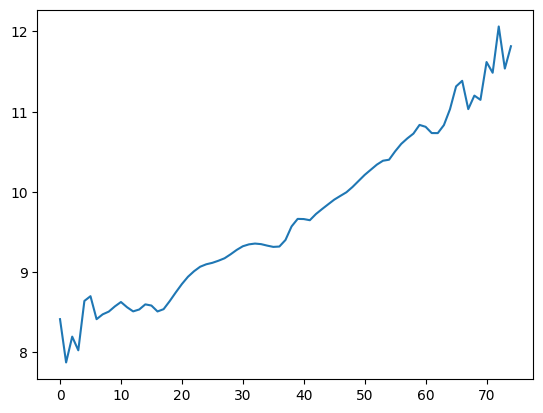

In [45]:
plt.plot(np.abs(V_meas-V_pred2) * 1000)

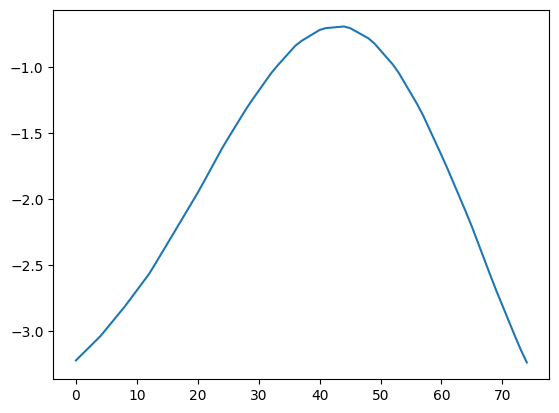

In [46]:
plt.plot(target_current)

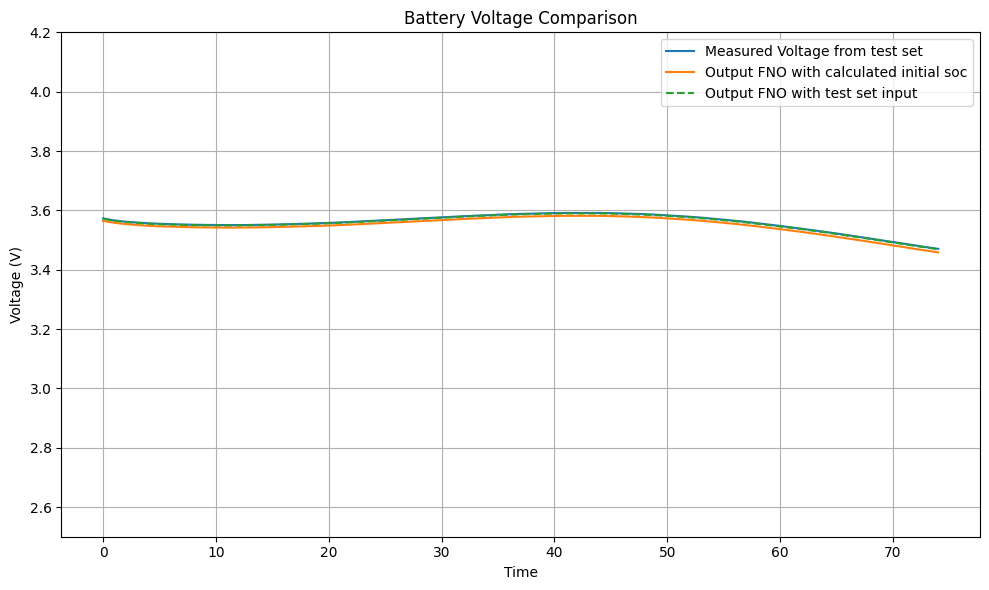

In [47]:
# Create a figure with a larger size for clarity
plt.figure(figsize=(10, 6))

# Plot the voltage data with labels for the legend
plt.plot(V_meas, label="Measured Voltage from test set")
plt.plot(V_pred2, label="Output FNO with calculated initial soc")
plt.plot(V_pred3, linestyle = "--", label="Output FNO with test set input")

# Label axes and add a title
plt.xlabel("Time")
plt.ylabel("Voltage (V)")
plt.title("Battery Voltage Comparison")

# Set y-axis limits based on battery parameters from pybamm
plt.ylim(params_bat["Lower voltage cut-off [V]"], params_bat["Upper voltage cut-off [V]"])

# Add grid lines and legend
plt.grid(True)
plt.legend()

# Adjust layout for better spacing and display the plot
plt.tight_layout()
plt.show()

In [48]:
c0_av = jnp.mean(c0_anode_sol[best_idx])
soc_from_c0_anode(c0_av)

Array(0.3906379, dtype=float32)

In [49]:
soc_true = soc_from_c0_anode(jnp.mean(test_c0_anode[test_idx]))
soc_true

Array(0.39999995, dtype=float32)

In [50]:
soc_cathode = soc_from_c0_cathode(jnp.mean(c0_cathode_sol[best_idx]))
soc_cathode

Array(0.39063823, dtype=float32)

In [51]:
soc_cathode_true = soc_from_c0_cathode(jnp.mean(test_c0_cathode[test_idx]))
soc_cathode_true

Array(0.4000002, dtype=float32)

In [52]:
spm = pybamm.lithium_ion.SPM()
sim = pybamm.Simulation(spm, parameter_values=params_bat)
sim.parameter_values["Current function [A]"] = pybamm.Interpolant(t, -1.0 * target_current, pybamm.t)
sol = sim.solve(initial_soc=0.3, t_eval=t)

In [53]:
soc-soc_true

Array(0.6, dtype=float32)